# ERA5-Land Postage Stamp Maps: DA − OL (Surface + RZ)

This notebook builds **postage stamp** map figures for ERA5-Land comparison metrics:
- `R`
- `anomR`
- `ubRMSE`

Layout:
- **6 rows x 3 columns**
- Top 3 rows: **Surface SM** (`R`, `anomR`, `ubRMSE`)
- Bottom 3 rows: **Root-zone SM** (`R`, `anomR`, `ubRMSE`)
- Columns: the first 3 time periods.

Note on colorbars:
- A single colorbar is not used because `ubRMSE` has different units (`m$^3$ m$^{-3}$`) than `R`/`anomR`.
- Instead, the figure uses **3 shared colorbars** (one per metric, each shared across Surface + RZ rows).


In [1]:
from pathlib import Path
import sys
import hashlib
import json as pyjson

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# ---- Paths ----
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / '.git').exists():
    REPO_ROOT = REPO_ROOT.parent

FN_DA = str(REPO_ROOT / 'projects/era5_land/notebooks/ERA5L_vs_DAv8_M36_strict_summary.nc')
FN_OL = str(REPO_ROOT / 'projects/era5_land/notebooks/ERA5L_vs_OLv8_M36_strict_summary.nc')
FILES = [FN_DA, FN_OL]

# ---- Settings ----
MIN_PAIRS = 24
SNOW_EPS = 1e-6
PERIODS = [
    ('2000-06-01', '2007-05-31'),
    ('2007-06-01', '2015-03-31'),
    ('2015-04-01', '2024-05-31'),
    ('2000-06-01', '2024-05-31'),
]

CACHE_DIR = REPO_ROOT / 'cache' / 'era5_periodized_metrics'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = REPO_ROOT / 'projects/era5_land/notebooks/figures_era5l_postage_stamps'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('REPO_ROOT:', REPO_ROOT)
print('FN_DA:', FN_DA)
print('FN_OL:', FN_OL)
print('MIN_PAIRS:', MIN_PAIRS)
print('CACHE_DIR:', CACHE_DIR)
print('FIG_DIR:', FIG_DIR)


REPO_ROOT: /Users/amfox/Desktop/geosldas-analysis
FN_DA: /Users/amfox/Desktop/geosldas-analysis/projects/era5_land/notebooks/ERA5L_vs_DAv8_M36_strict_summary.nc
FN_OL: /Users/amfox/Desktop/geosldas-analysis/projects/era5_land/notebooks/ERA5L_vs_OLv8_M36_strict_summary.nc
MIN_PAIRS: 24
CACHE_DIR: /Users/amfox/Desktop/geosldas-analysis/cache/era5_periodized_metrics
FIG_DIR: /Users/amfox/Desktop/geosldas-analysis/projects/era5_land/notebooks/figures_era5l_postage_stamps


In [2]:
def anomalies_monthly(da, dim='time'):
    clim = da.groupby(f'{dim}.month').mean(dim=dim, skipna=True)
    return da.groupby(f'{dim}.month') - clim


def anom_metrics_monthly(a, b, dim='time', min_pairs=24):
    a_v = anomalies_monthly(a, dim=dim)
    b_v = anomalies_monthly(b, dim=dim)

    valid = np.isfinite(a_v) & np.isfinite(b_v)
    n = valid.sum(dim=dim)

    anomR = xr.corr(a_v.where(valid), b_v.where(valid), dim=dim)
    ubRMSE = xr.ufuncs.sqrt(((a_v - b_v) ** 2).mean(dim=dim, skipna=True))

    anomR = xr.where(n >= min_pairs, anomR, np.nan)
    ubRMSE = xr.where(n >= min_pairs, ubRMSE, np.nan)
    return anomR, ubRMSE


def corr_monthly(a, b, dim='time', min_pairs=24):
    valid = np.isfinite(a) & np.isfinite(b)
    n = valid.sum(dim=dim)
    r = xr.corr(a.where(valid), b.where(valid), dim=dim)
    return xr.where(n >= min_pairs, r, np.nan)


def _apply_era5l_no_snow_zero(ds):
    # Keep consistency with other ERA5-Land workflows.
    out = ds.copy()
    for v in ('SWE_era', 'SNWD_era'):
        if v in out:
            out[v] = out[v].fillna(0.0)
    return out


def compute_metrics_for_period(ds, t0, t1, min_pairs=24, snow_eps=1e-6):
    sub = ds.sel(time=slice(t0, t1))

    sm_mod_raw = sub['SM_model'].astype('float64')
    sm_era_raw = sub['SM_era'].astype('float64')
    sm_mod_an = anomalies_monthly(sm_mod_raw, dim='time')
    sm_era_an = anomalies_monthly(sm_era_raw, dim='time')

    anomR_sfc, ubRMSE_sfc = anom_metrics_monthly(sm_mod_an, sm_era_an, min_pairs=min_pairs)
    R_sfc = corr_monthly(sm_mod_raw, sm_era_raw, min_pairs=min_pairs)

    rz_mod_name = 'RZ_model' if 'RZ_model' in sub else ('RZMC_model' if 'RZMC_model' in sub else None)
    rz_era_name = 'RZ_era' if 'RZ_era' in sub else ('RZMC_era' if 'RZMC_era' in sub else None)

    if (rz_mod_name is not None) and (rz_era_name is not None):
        rz_mod_raw = sub[rz_mod_name].astype('float64')
        rz_era_raw = sub[rz_era_name].astype('float64')
        rz_mod_an = anomalies_monthly(rz_mod_raw, dim='time')
        rz_era_an = anomalies_monthly(rz_era_raw, dim='time')

        anomR_rz, ubRMSE_rz = anom_metrics_monthly(rz_mod_an, rz_era_an, min_pairs=min_pairs)
        R_rz = corr_monthly(rz_mod_raw, rz_era_raw, min_pairs=min_pairs)
    else:
        anomR_rz = xr.full_like(anomR_sfc, np.nan)
        ubRMSE_rz = xr.full_like(ubRMSE_sfc, np.nan)
        R_rz = xr.full_like(anomR_sfc, np.nan)

    return xr.Dataset(
        data_vars=dict(
            R_sfc=R_sfc,
            anomR_sfc=anomR_sfc,
            ubRMSE_sfc=ubRMSE_sfc,
            R_rz=R_rz,
            anomR_rz=anomR_rz,
            ubRMSE_rz=ubRMSE_rz,
            lat=(('y', 'x'), sub['lat'].values),
            lon=(('y', 'x'), sub['lon'].values),
        )
    )


def _cache_file_for(fn, periods, min_pairs):
    payload = {
        'input_file': str(Path(fn).resolve()),
        'periods': periods,
        'min_pairs': int(min_pairs),
        'schema': 'periodized_maps_sm_only_v2_rznamefix',
    }
    key = hashlib.sha1(pyjson.dumps(payload, sort_keys=True).encode()).hexdigest()[:12]
    stem = Path(fn).stem
    return CACHE_DIR / f'{stem}__{key}.nc'


In [3]:
import time

results = {}
required_data_vars = {'R_sfc', 'anomR_sfc', 'ubRMSE_sfc', 'R_rz', 'anomR_rz', 'ubRMSE_rz'}
target_period_labels = [f'{t0}–{t1}' for (t0, t1) in PERIODS]


def _has_lat_lon(ds):
    return (
        ('lat' in ds.coords or 'lat' in ds.data_vars)
        and ('lon' in ds.coords or 'lon' in ds.data_vars)
    )


def _is_compatible_cache(ds, need_data_vars, need_periods):
    if not need_data_vars.issubset(set(ds.data_vars)):
        return False
    if not _has_lat_lon(ds):
        return False
    if 'period' not in ds.coords:
        return False
    have_periods = [str(p) for p in ds['period'].values]
    if have_periods != need_periods:
        return False

    # Guard against old caches built with wrong RZ variable names.
    try:
        has_sfc = bool(np.isfinite(np.asarray(ds['R_sfc'].values)).any())
        has_rz = bool(np.isfinite(np.asarray(ds['R_rz'].values)).any())
    except Exception:
        return False
    if not (has_sfc and has_rz):
        return False

    return True


def _find_compatible_cache(fn, need_data_vars, need_periods):
    stem = Path(fn).stem
    candidates = sorted(CACHE_DIR.glob(f'{stem}__*.nc'), key=lambda q: q.stat().st_mtime, reverse=True)
    for cand in candidates:
        try:
            ds = xr.open_dataset(cand)
        except Exception:
            continue
        ok = _is_compatible_cache(ds, need_data_vars, need_periods)
        if ok:
            return ds, cand
        ds.close()
    return None, None


for fn in FILES:
    t_file0 = time.time()
    cache_file = _cache_file_for(fn, PERIODS, MIN_PAIRS)

    ds_all = None

    # 1) Exact cache key
    if cache_file.exists():
        ds_try = xr.open_dataset(cache_file)
        if _is_compatible_cache(ds_try, required_data_vars, target_period_labels):
            ds_all = ds_try
            print(f'Loaded exact cache: {cache_file}')
        else:
            ds_try.close()

    # 2) Compatible cache fallback (lets this notebook reuse bar-notebook caches)
    if ds_all is None:
        ds_fallback, cf = _find_compatible_cache(fn, required_data_vars, target_period_labels)
        if ds_fallback is not None:
            ds_all = ds_fallback
            print(f'Loaded compatible cache: {cf}')

    # 3) Recompute only if needed
    if ds_all is None:
        print(f'Recomputing periodized metrics for: {fn}')
        ds = xr.open_dataset(fn)
        ds = _apply_era5l_no_snow_zero(ds)

        per_list = []
        per_labels = []
        for t0, t1 in PERIODS:
            t_per = time.time()
            ds_per = compute_metrics_for_period(ds, t0, t1, min_pairs=MIN_PAIRS, snow_eps=SNOW_EPS)
            per_list.append(ds_per)
            per_labels.append(f'{t0}–{t1}')
            print(
                f'  {t0} to {t1}: mean R_sfc={float(ds_per["R_sfc"].mean(skipna=True)):.3f} '
                f'[{time.time() - t_per:.1f}s]'
            )

        ds_all = xr.concat(per_list, dim=xr.DataArray(per_labels, dims=('period',), name='period'))
        ds_all.to_netcdf(cache_file)
        print(f'Saved cached periodized metrics: {cache_file}')

    results[fn] = ds_all
    print(f'Finished {Path(fn).name} in {time.time() - t_file0:.1f}s')


if (FN_DA in results) and (FN_OL in results):
    common = sorted(set(results[FN_DA].data_vars).intersection(set(results[FN_OL].data_vars)))
    diff_vars = {}
    for v in common:
        if v in ('lat', 'lon'):
            continue
        diff_vars[v] = (results[FN_DA][v] - results[FN_OL][v])
    diff_period = xr.Dataset(diff_vars)
    diff_period['lat'] = results[FN_DA]['lat']
    diff_period['lon'] = results[FN_DA]['lon']
    print("Built DA−OL periodized metrics in 'diff_period' (dims:", diff_period.dims, ')')
else:
    raise RuntimeError('Expected FN_DA/FN_OL in results.')



Loaded exact cache: /Users/amfox/Desktop/geosldas-analysis/cache/era5_periodized_metrics/ERA5L_vs_DAv8_M36_strict_summary__018c5d8cd34d.nc
Finished ERA5L_vs_DAv8_M36_strict_summary.nc in 1.1s
Loaded exact cache: /Users/amfox/Desktop/geosldas-analysis/cache/era5_periodized_metrics/ERA5L_vs_OLv8_M36_strict_summary__10055848b28e.nc
Finished ERA5L_vs_OLv8_M36_strict_summary.nc in 0.0s
Built DA−OL periodized metrics in 'diff_period' (dims: FrozenMappingWarningOnValuesAccess({'y': 379, 'x': 964, 'period': 4}) )


tilecoord: /Users/amfox/Desktop/geosldas-analysis/outputs_daily_snow_seasonal_ol_da/LS_OLv8_M36.ldas_tilecoord.bin
Using all positive frac_cell weights (cells=112573)
Finite count R_sfc: 373543
Finite count anomR_sfc: 373543
Finite count ubRMSE_sfc: 374591
Finite count R_rz: 349058
Finite count anomR_rz: 348109
Finite count ubRMSE_rz: 349157


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: inv

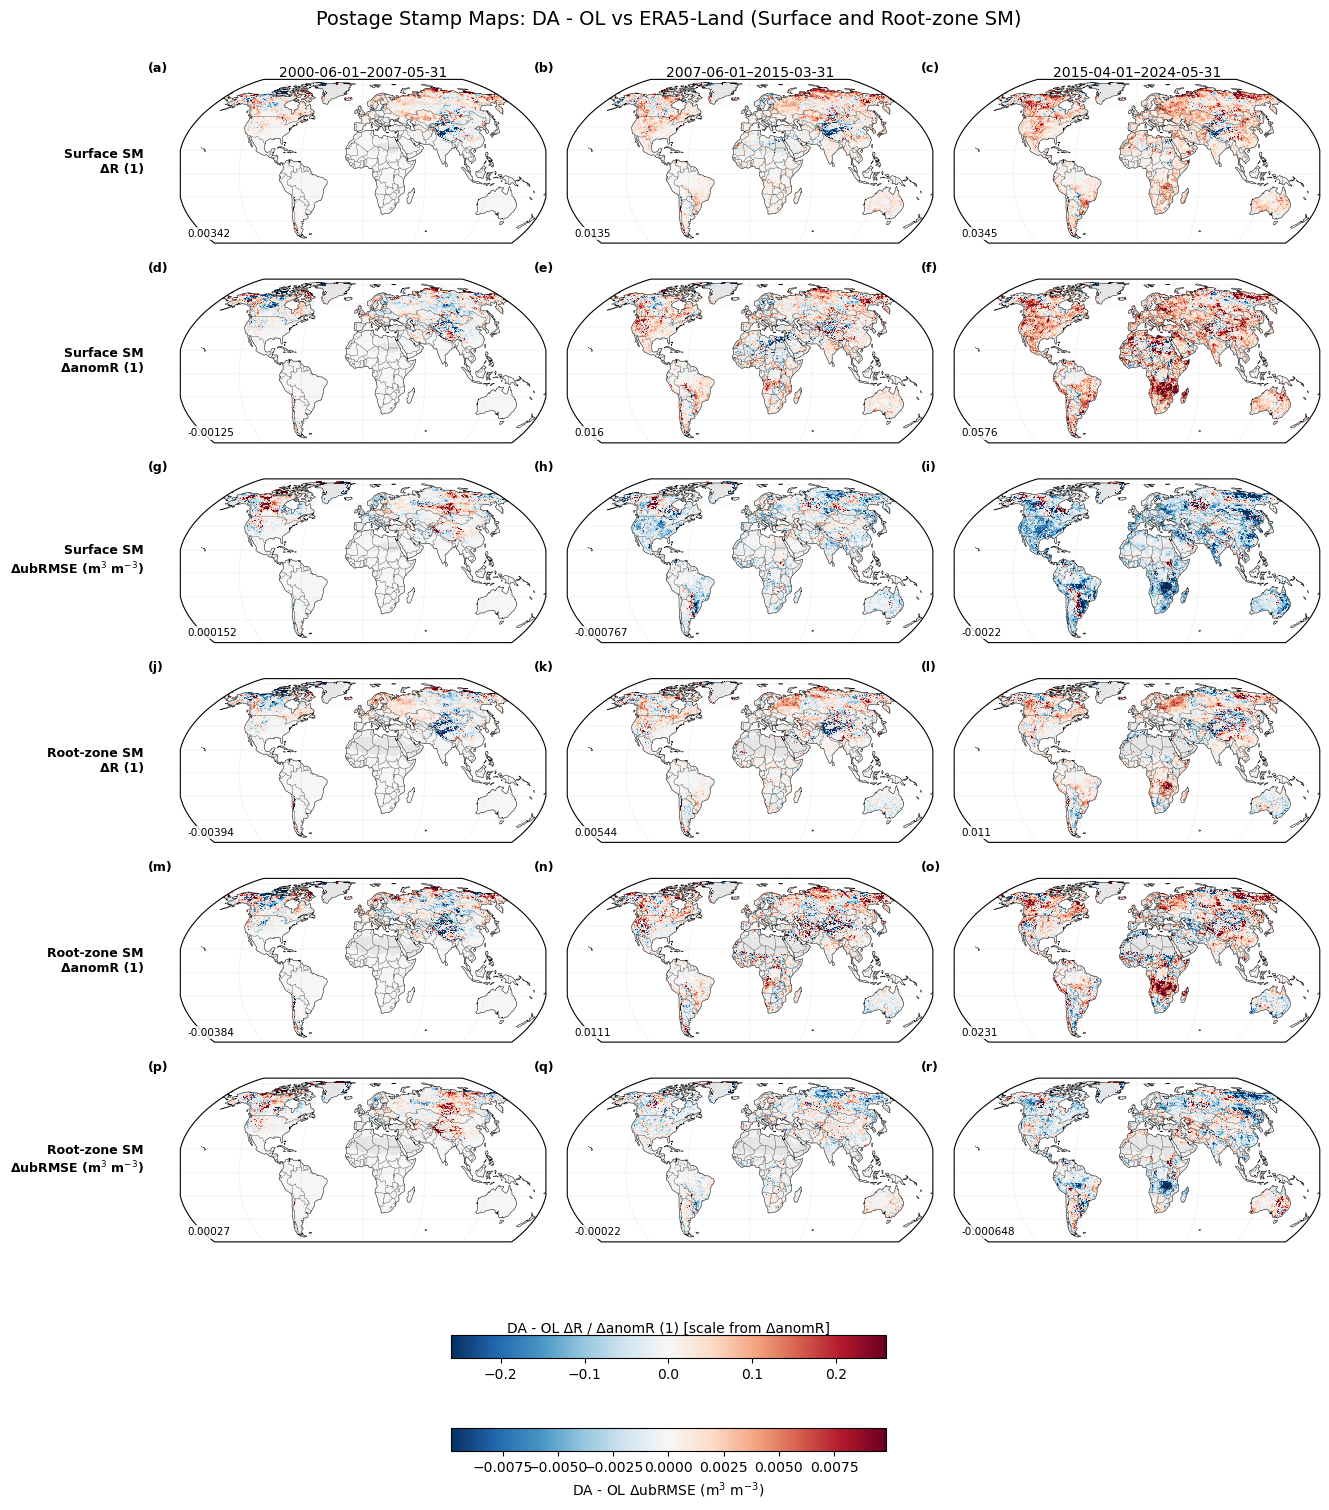

Saved: /Users/amfox/Desktop/geosldas-analysis/projects/era5_land/notebooks/figures_era5l_postage_stamps/postage_stamp_da_minus_ol_surface_rz_sm_6x3.png


In [4]:
# --- Postage stamp figure: 6x3 (rows=Surface/RZ metric rows, cols=3 periods) ---
import struct
import cartopy.feature as cfeature

if 'diff_period' not in globals():
    raise RuntimeError("diff_period not found. Run the metrics cell first.")

LAT_MIN_SM = float(globals().get('LAT_MIN', -60.0))
SAVE_PDF = False  # set True only if you need vector output

period_labels = [str(p) for p in diff_period['period'].values]
if len(period_labels) < 3:
    raise RuntimeError(f'Need at least 3 periods; found {len(period_labels)}')
period_subset = period_labels[:3]

# Use canonical finite EASE coordinates for plotting (strict pcolormesh, no fallback).
ny, nx = diff_period['R_sfc'].isel(period=0).shape

EASE_PATH = REPO_ROOT / 'common' / 'python' / 'plotting' / 'ease_grids'
lat_full = np.fromfile(str(EASE_PATH / 'EASE2_M36km.lats.964x406x1.double'), dtype=np.float64).reshape((406, 964))
lon_full = np.fromfile(str(EASE_PATH / 'EASE2_M36km.lons.964x406x1.double'), dtype=np.float64).reshape((406, 964))

if (nx != 964) or (ny > 406):
    raise RuntimeError(f'Strict data grid {(ny, nx)} is incompatible with EASE grid {(406, 964)}')

lat_plot = lat_full[:ny, :]
lon_plot = lon_full[:ny, :]

if lat_plot.shape != (ny, nx) or lon_plot.shape != (ny, nx):
    raise RuntimeError(
        f'EASE lat/lon shape mismatch: lat={lat_plot.shape}, lon={lon_plot.shape}, data={(ny, nx)}'
    )

if not (np.isfinite(lat_plot).all() and np.isfinite(lon_plot).all()):
    raise RuntimeError('EASE plotting lon/lat must be fully finite for strict pcolormesh mode.')


def _pick_existing_local(*candidates):
    for c in candidates:
        if c is None:
            continue
        pth = Path(c)
        if pth.exists():
            return pth
    raise FileNotFoundError('Could not find any of: ' + ', '.join(str(Path(c)) for c in candidates if c is not None))


def _read_tilecoord_local(fname):
    fields = [
        'tile_id', 'typ', 'pfaf', 'com_lon', 'com_lat', 'min_lon', 'max_lon',
        'min_lat', 'max_lat', 'i_indg', 'j_indg', 'frac_cell', 'frac_pfaf',
        'area', 'elev'
    ]
    ints = {'tile_id', 'typ', 'pfaf', 'i_indg', 'j_indg'}

    out = {}
    with open(fname, 'rb') as f:
        _ = struct.unpack('<i', f.read(4))[0]
        nt = struct.unpack('<i', f.read(4))[0]
        _ = struct.unpack('<i', f.read(4))[0]

        for fld in fields:
            _ = struct.unpack('<i', f.read(4))[0]
            dtype = 'i' if fld in ints else 'f'
            arr = np.frombuffer(f.read(nt * 4), dtype=f'<{dtype}')
            out[fld] = arr.astype(np.int32 if dtype == 'i' else np.float64)
            _ = struct.unpack('<i', f.read(4))[0]
    return out


def _land_frac_m36_from_tilecoord_local(tc):
    ix = tc['i_indg'].astype(np.int64)
    iy = tc['j_indg'].astype(np.int64)

    if ix.min() == 1 and iy.min() == 1:
        ix = ix - 1
        iy = iy - 1
    elif ix.min() != 0 or iy.min() != 0:
        ix = ix - ix.min()
        iy = iy - iy.min()

    frac = tc['frac_cell'].astype(np.float64)
    typ = tc['typ'].astype(np.int64)
    finite_pos = np.isfinite(frac) & (frac > 0)

    ny_local = int(iy.max()) + 1
    nx_local = int(ix.max()) + 1

    w_all = np.zeros((ny_local, nx_local), dtype=np.float64)
    np.add.at(w_all, (iy[finite_pos], ix[finite_pos]), frac[finite_pos])

    typ1 = finite_pos & (typ == 1)
    w_typ1 = np.zeros((ny_local, nx_local), dtype=np.float64)
    if np.any(typ1):
        np.add.at(w_typ1, (iy[typ1], ix[typ1]), frac[typ1])

    nnz_all = int(np.count_nonzero(w_all > 0))
    nnz_typ1 = int(np.count_nonzero(w_typ1 > 0))

    if nnz_typ1 > 0 and nnz_typ1 >= max(1000, int(0.2 * max(nnz_all, 1))):
        w = w_typ1
        print(f'Using typ==1 weights (cells={nnz_typ1})')
    else:
        w = w_all
        print(f'Using all positive frac_cell weights (cells={nnz_all})')

    return w


# Land-fraction weights for weighted panel means.
fn_tilecoord = _pick_existing_local(
    REPO_ROOT / 'outputs_daily_snow_seasonal_ol_da/LS_OLv8_M36.ldas_tilecoord.bin',
    Path.cwd() / 'outputs_daily_snow_seasonal_ol_da/LS_OLv8_M36.ldas_tilecoord.bin',
    Path('/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/land_sweeper/LS_OLv8_M36/output/SMAP_EASEv2_M36_GLOBAL/rc_out/LS_OLv8_M36.ldas_tilecoord.bin'),
)
print('tilecoord:', fn_tilecoord)
tc = _read_tilecoord_local(fn_tilecoord)
w_land = _land_frac_m36_from_tilecoord_local(tc)

if w_land.shape != lat_plot.shape:
    raise RuntimeError(
        f'land-fraction shape {w_land.shape} must match strict-summary grid {lat_plot.shape}. '
        'Use a tilecoord built for the same strict domain.'
    )

# Row definitions for 6x3 layout
row_defs = [
    ('Surface SM', 'R_sfc', 'ΔR (1)', 'R'),
    ('Surface SM', 'anomR_sfc', 'ΔanomR (1)', 'anomR'),
    ('Surface SM', 'ubRMSE_sfc', 'ΔubRMSE (m$^3$ m$^{-3}$)', 'ubRMSE'),
    ('Root-zone SM', 'R_rz', 'ΔR (1)', 'R'),
    ('Root-zone SM', 'anomR_rz', 'ΔanomR (1)', 'anomR'),
    ('Root-zone SM', 'ubRMSE_rz', 'ΔubRMSE (m$^3$ m$^{-3}$)', 'ubRMSE'),
]

metric_cfg = {
    'R': {'fields': ('R_sfc', 'R_rz'), 'cmap': 'RdBu_r'},
    'anomR': {'fields': ('anomR_sfc', 'anomR_rz'), 'cmap': 'RdBu_r'},
    'ubRMSE': {'fields': ('ubRMSE_sfc', 'ubRMSE_rz'), 'cmap': 'RdBu_r'},
}


def _plot_postage_panel(ax, lon2d, lat2d, z2d, w2d, cmap, vlim, lat_min=-60.0):
    z = np.asarray(z2d, dtype=float)

    keep_lat = np.isfinite(lat2d) & (lat2d >= lat_min)
    finite_xy_local = np.isfinite(lon2d) & np.isfinite(lat2d) & keep_lat
    z = np.where(keep_lat, z, np.nan)
    finite_all = finite_xy_local & np.isfinite(z)

    ax.set_global()
    ax.set_extent([-180.0, 180.0, lat_min, 90.0], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='0.9', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.35, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, zorder=2)
    _ = ax.gridlines(draw_labels=False, linewidth=0.30, color='gray', alpha=0.30, linestyle='--')

    if int(finite_all.sum()) == 0:
        ax.text(0.5, 0.5, 'No finite data', ha='center', va='center', transform=ax.transAxes, fontsize=8)
        return None, np.nan

    if not bool(np.all(finite_xy_local)):
        raise RuntimeError(
            'Non-finite lon/lat encountered inside plot panel; no scatter fallback is allowed in this notebook.'
        )

    artist = ax.pcolormesh(
        lon2d,
        lat2d,
        z,
        transform=ccrs.PlateCarree(),
        shading='auto',
        cmap=cmap,
        vmin=vlim[0],
        vmax=vlim[1],
        zorder=1,
        rasterized=True,
    )

    # Land-fraction-weighted spatial mean
    valid_w = finite_all & np.isfinite(w2d) & (w2d > 0)
    if int(valid_w.sum()) > 0:
        spatial_mean = float(np.nansum(z[valid_w] * w2d[valid_w]) / np.nansum(w2d[valid_w]))
    else:
        spatial_mean = np.nan

    ax.text(
        0.02,
        0.03,
        f'{spatial_mean:.3g}',
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=7.5,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.2),
        zorder=3,
    )
    return artist, spatial_mean


# Limits:
#  - R uses the anomR range (as requested)
#  - anomR uses its own range
#  - ubRMSE uses its own range

def _pooled_abs_p98(fields):
    vals = []
    keep_lat = np.isfinite(lat_plot) & np.isfinite(lon_plot) & (lat_plot >= LAT_MIN_SM)
    for f in fields:
        if f not in diff_period:
            continue
        for per in period_subset:
            z = np.asarray(diff_period[f].sel(period=per).values, dtype=float)
            z = np.where(keep_lat, z, np.nan)
            zz = z[np.isfinite(z)]
            if zz.size:
                vals.append(zz)
    if vals:
        v = np.concatenate(vals)
        lim = float(np.nanpercentile(np.abs(v), 98.0))
        return max(lim, 1e-6)
    return 1.0

lim_anom = _pooled_abs_p98(metric_cfg['anomR']['fields'])
lim_ub = _pooled_abs_p98(metric_cfg['ubRMSE']['fields'])
lims = {'R': lim_anom, 'anomR': lim_anom, 'ubRMSE': lim_ub}

# quick diagnostics
for _f in ['R_sfc', 'anomR_sfc', 'ubRMSE_sfc', 'R_rz', 'anomR_rz', 'ubRMSE_rz']:
    if _f in diff_period:
        _n = int(np.isfinite(np.asarray(diff_period[_f].values)).sum())
        print(f'Finite count {_f}: {_n}')

if int(np.isfinite(np.asarray(diff_period['R_rz'].values)).sum()) == 0:
    raise RuntimeError('R_rz is all-NaN. Re-run metric/cache cell to rebuild with RZ_model/RZ_era.')

fig, axs = plt.subplots(
    6,
    3,
    figsize=(13.6, 15.5),
    subplot_kw={'projection': ccrs.Robinson()},
)
axs = np.asarray(axs)

mesh_ref = {'R': None, 'anomR': None, 'ubRMSE': None}

for r, (group_name, field, ylabel, mkey) in enumerate(row_defs):
    for c, per in enumerate(period_subset):
        ax = axs[r, c]

        z = np.asarray(diff_period[field].sel(period=per).values, dtype=float)
        artist, spatial_mean = _plot_postage_panel(
            ax=ax,
            lon2d=lon_plot,
            lat2d=lat_plot,
            z2d=z,
            w2d=w_land,
            cmap=metric_cfg[mkey]['cmap'],
            vlim=(-lims[mkey], lims[mkey]),
            lat_min=LAT_MIN_SM,
        )
        if (mesh_ref[mkey] is None) and (artist is not None):
            mesh_ref[mkey] = artist

        if r == 0:
            ax.set_title(per, fontsize=10, pad=2)

        if c == 0:
            ax.text(
                -0.10,
                0.5,
                f'{group_name}\n{ylabel}',
                transform=ax.transAxes,
                ha='right',
                va='center',
                fontsize=9,
                fontweight='bold',
            )

        idx = r * len(period_subset) + c
        ax.text(
            -0.09,
            1.03,
            f'({chr(97 + idx)})',
            transform=ax.transAxes,
            ha='left',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            clip_on=False,
        )

# Layout + bottom colorbars
fig.subplots_adjust(left=0.14, right=0.98, top=0.94, bottom=0.19, hspace=0.22, wspace=0.05)

cbar_left = 0.34
cbar_width = 0.32
cbar_h = 0.015

# Shared bar for R + anomR (uses anomR scale)
if mesh_ref['anomR'] is not None:
    cax1 = fig.add_axes([cbar_left, 0.115, cbar_width, cbar_h])
    cb1 = fig.colorbar(mesh_ref['anomR'], cax=cax1, orientation='horizontal')
    cb1.set_label('DA - OL ΔR / ΔanomR (1) [scale from ΔanomR]', fontsize=10, labelpad=2)
    cb1.ax.xaxis.set_label_position('top')

# ubRMSE bar
if mesh_ref['ubRMSE'] is not None:
    cax2 = fig.add_axes([cbar_left, 0.055, cbar_width, cbar_h])
    cb2 = fig.colorbar(mesh_ref['ubRMSE'], cax=cax2, orientation='horizontal')
    cb2.set_label('DA - OL ΔubRMSE (m$^3$ m$^{-3}$)', fontsize=10)

fig.suptitle('Postage Stamp Maps: DA - OL vs ERA5-Land (Surface and Root-zone SM)', fontsize=14, y=0.985)

out_png = FIG_DIR / 'postage_stamp_da_minus_ol_surface_rz_sm_6x3.png'
out_pdf = FIG_DIR / 'postage_stamp_da_minus_ol_surface_rz_sm_6x3.pdf'
fig.savefig(out_png, dpi=220, bbox_inches='tight')
if SAVE_PDF:
    fig.savefig(out_pdf, dpi=220, bbox_inches='tight')
plt.show()

print('Saved:', out_png)
if SAVE_PDF:
    print('Saved:', out_pdf)





